# Student Performance AI

## Notebook 05 — Model Evaluation

### Objective

In this notebook we will evaluate the trained neural network on unseen test data.

We will:

- Load the trained model
- Generate predictions
- Calculate MAE
- Calculate MSE
- Calculate RMSE
- Calculate R²
- Compare actual vs predicted values
- Analyze prediction errors
- Check the model's generalization performance

The test dataset contains students that were not used during model training.

In [1]:
import sys
from pathlib import Path

import torch
import torch.nn as nn

import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from torch.utils.data import DataLoader

## Project Path 

In [2]:
project_root = Path.cwd().parent

sys.path.append(str(project_root))

print(project_root)

f:\ML\AI_Engineering\AI-Engineering-Bootcamp\Projects\student-performance-ai


## Load Preprocess Data

In [3]:
from src.preprocessing import preprocess_data

X_train_tensor, X_test_tensor, y_train_tensor, y_test_tensor = preprocess_data(
    "../data/raw/student-performance.csv"
)

print("X_test:", X_test_tensor.shape)
print("y_test:", y_test_tensor.shape)

X_test: torch.Size([130, 58])
y_test: torch.Size([130, 1])


## Recreate the Model Architecture

This is important.

PyTorch's .pth file contains the learned parameters, but we need to recreate the model architecture before loading them.

In [4]:
class StudentPerformanceModel(nn.Module):

    def __init__(self, input_size):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.ReLU(),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.network(x)

## Load Model

In [5]:
input_size = X_test_tensor.shape[1]

model = StudentPerformanceModel(input_size)

model_path = project_root / "models" / "checkpoints" / "student_performance_model.pth"

model.load_state_dict(
    torch.load(
        model_path,
        map_location="cpu"
    )
)

model.eval()

print("Model loaded successfully.")

Model loaded successfully.


## Generate Predictions

In [6]:
with torch.no_grad():

    predictions = model(X_test_tensor)

print("Prediction shape:", predictions.shape)
print("Actual shape:", y_test_tensor.shape)

Prediction shape: torch.Size([130, 1])
Actual shape: torch.Size([130, 1])


## Convert to the numpy

In [7]:
y_true = y_test_tensor.numpy().flatten()
y_pred = predictions.numpy().flatten()

print("Actual:", y_true[:5])
print("Predicted:", y_pred[:5])

Actual: [19. 12. 18. 11. 11.]
Predicted: [18.500778 11.342331 19.221975 11.118462 12.771137]


### Mean Absolute Error

MAE represents the average absolute difference between the actual and predicted values.

MAE is easy to interpret because it is expressed in the same units as the target.

In [8]:
mae = mean_absolute_error(
    y_true,
    y_pred
)

print(f"MAE: {mae:.4f}")

MAE: 0.9209


In [9]:
mse = mean_squared_error(
    y_true,
    y_pred
)

print(f"MSE: {mse:.4f}")

MSE: 2.0402


In [12]:
rmse = np.sqrt(mse)
rmse

np.float64(1.4283552789652854)

In [10]:
r2 = r2_score(
    y_true,
    y_pred
)

print(f"R²: {r2:.4f}")

R²: 0.7908


## Evaluation Report


In [13]:
print("=" * 40)
print("MODEL EVALUATION")
print("=" * 40)


print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

MODEL EVALUATION
MAE  : 0.9209
MSE  : 2.0402
RMSE : 1.4284
R²   : 0.7908


**Actual vs Predicted**

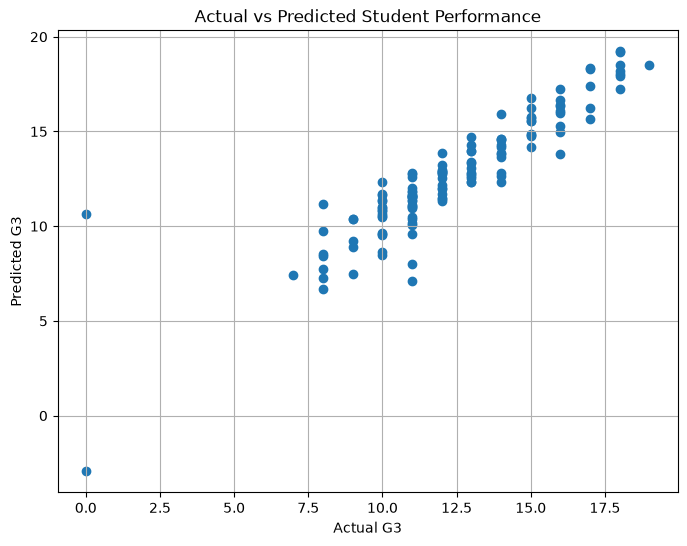

In [14]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_true,
    y_pred
)

plt.xlabel("Actual G3")
plt.ylabel("Predicted G3")
plt.title("Actual vs Predicted Student Performance")

plt.grid(True)
plt.show()

## Prediction Error

In [15]:
residuals = y_true - y_pred

print("Mean residual:", residuals.mean())
print("Minimum residual:", residuals.min())
print("Maximum residual:", residuals.max())

Mean residual: -0.30149207
Minimum residual: -10.649935
Maximum residual: 3.8709955


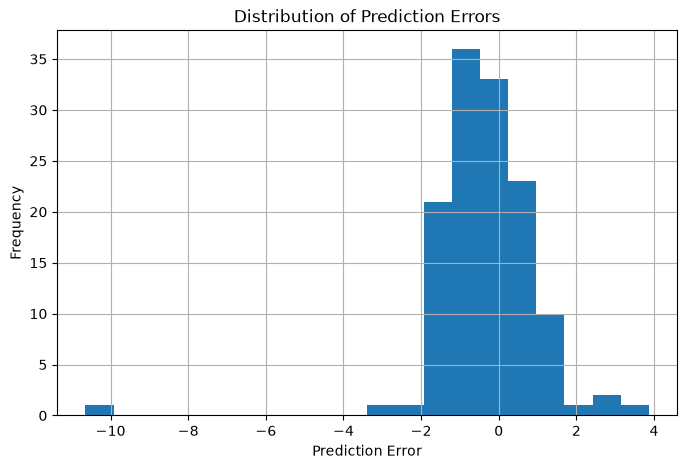

In [16]:
plt.figure(figsize=(8, 5))

plt.hist(
    residuals,
    bins=20
)

plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.title("Distribution of Prediction Errors")

plt.grid(True)
plt.show()